<a href="https://colab.research.google.com/github/5und4r/MachineLearningLab/blob/main/MachineLearningLabII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 1 : CAR PRICE PREDICTION USING REGRESSION

## Problem Statement

A automobile company maintains a dataset containing information about different cars, including their fuel type, body style, engine characteristics, dimensions, horsepower, mileage, and other specifications.
Develop a Python-based Machine Learning system to analyze the dataset and build a regression model for predicting the price of a car.


In [ ]:
from numpy import empty
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as linreg

## 1. Loading and Exploring the Dataset


In [ ]:
# Loading the dataset
df = pd.read_csv('CarPriceData.csv')
if not df.empty :
  print("Successfully loaded dataset")
else:
  print("error loading dataset")

print(f"Number of Rows : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}\n")

print("Numerical and Categorical Attributes : ")
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numerical Attributes : {numerical}")
print(f"Categorical Attributes : {categorical}\n")

print(f"Missing Values : {df.isnull().sum()}\n")
print(f"Duplicate Values : {df.duplicated().sum()}")

print("Statistical Summary : ")
display(df.describe())

print("First Five Rows : ")
display(df.head())
print("Last five rows :")
display(df.tail())

print("\nBaisc info :")
display(df.info())

Successfully loaded dataset
Number of Rows : 205
Number of columns : 26

Numerical and Categorical Attributes : 
Numerical Attributes : ['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']
Categorical Attributes : ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

Missing Values : car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower   

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


First Five Rows : 


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


Last five rows :


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625.0



Baisc info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null

None

In [ ]:
print(df['price'].max())
print(df['price'].min())

45400.0
5118.0


## 2. Data Preprocessing

In [ ]:
# Removing Irrelevant attributes safely
df = df.drop(columns=['car_ID'], errors='ignore')

# 1. Ordinal Encoding for 'aspiration'
ColsToEncode = ['aspiration']
ordinal_encoder = OrdinalEncoder(categories=[['std', 'turbo']])
df[ColsToEncode] = ordinal_encoder.fit_transform(df[ColsToEncode])

In [ ]:
# Onehot encoding

# 2. One-Hot Encoding for nominal columns using scikit-learn
ColsToEncodeOnehot = ['fueltype', 'carbody', 'drivewheel', 'enginetype']

encoderOneHot = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
OneHotEncodedData = encoderOneHot.fit_transform(df[ColsToEncodeOnehot])
display(df.head())

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,0.0,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,0.0,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,0.0,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,0.0,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,0.0,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
# Merging One Hot encoded data
OneHotdf = pd.DataFrame(OneHotEncodedData, columns=encoderOneHot.get_feature_names_out(ColsToEncodeOnehot), index=df.index)

df = pd.concat([df,OneHotdf],axis =1)
df = df.drop(columns=ColsToEncodeOnehot)
display(df.head())

,symboling,CarName,aspiration,doornumber,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,...,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,3,alfa-romero giulia,0.0,two,front,88.6,168.8,64.1,48.8,2548,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,alfa-romero stelvio,0.0,two,front,88.6,168.8,64.1,48.8,2548,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,alfa-romero Quadrifoglio,0.0,two,front,94.5,171.2,65.5,52.4,2823,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,audi 100 ls,0.0,four,front,99.8,176.6,66.2,54.3,2337,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2,audi 100ls,0.0,four,front,99.4,176.6,66.4,54.3,2824,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# Define the target variable (dependent variable)
y = df['price']

# Define the independent variables (features)
# We drop the target variable 'price', and optionally other non-numeric text columns like 'CarName' if not yet processed
X = df.drop(columns=['price'], errors='ignore')

# If 'CarName' or other raw string columns are still in X, we can drop them for the regression model
X = X.select_dtypes(include=['number'])

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nIndependent variables (X):")
display(X.head())

Shape of X: (205, 28)
Shape of y: (205,)

Independent variables (X):


,symboling,aspiration,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,3,0.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,0.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0.0,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,0.0,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2,0.0,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 3. Exploratory Data Analysis

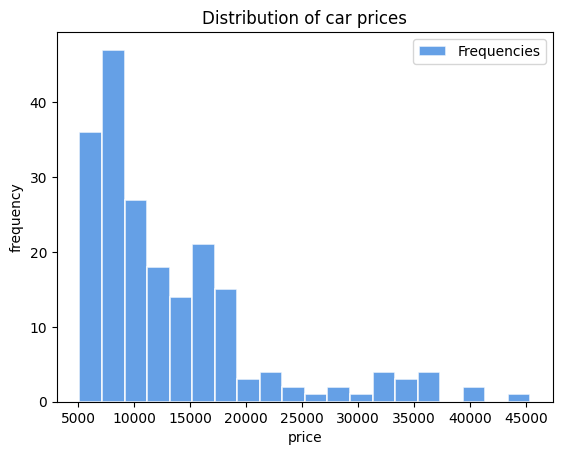

In [ ]:
# Distribution of prices
plt.hist(df['price'], bins=20, color='#4a90e2',
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85,
    label='Frequencies')
plt.xlabel('price')
plt.ylabel('frequency')
plt.title('Distribution of car prices')
plt.legend()
plt.show()

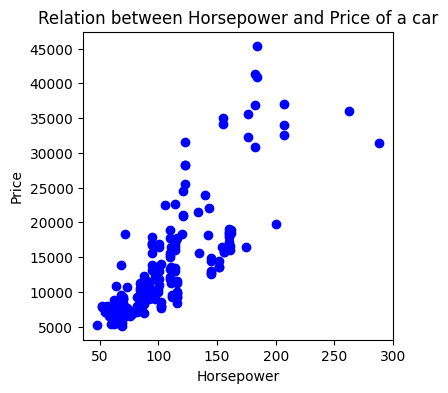

In [ ]:
plt.figure(figsize=(4,4))
# Relation between horse power and price
plt.scatter(df['horsepower'],df['price'],c='blue')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Relation between Horsepower and Price of a car')
plt.show()

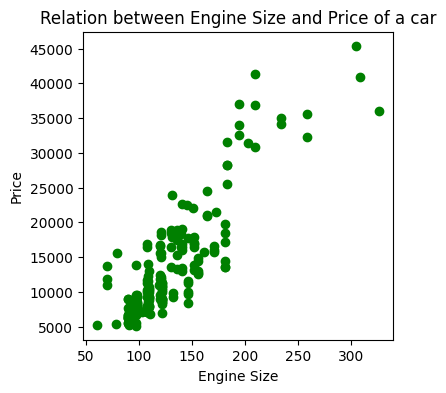

In [ ]:
plt.figure(figsize=(4,4))
#Relation between enginesize and price
plt.scatter(df['enginesize'],df['price'], c= 'green')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Relation between Engine Size and Price of a car')
plt.show()

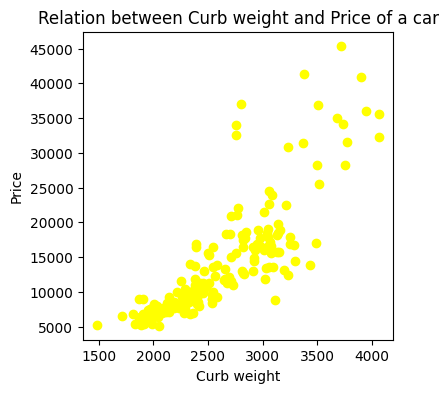

In [ ]:
plt.figure(figsize=(4,4))
#Relation between curbweight and price
plt.scatter(df['curbweight'],df['price'], c = 'yellow')
plt.xlabel('Curb weight')
plt.ylabel('Price')
plt.title('Relation between Curb weight and Price of a car')
plt.show()

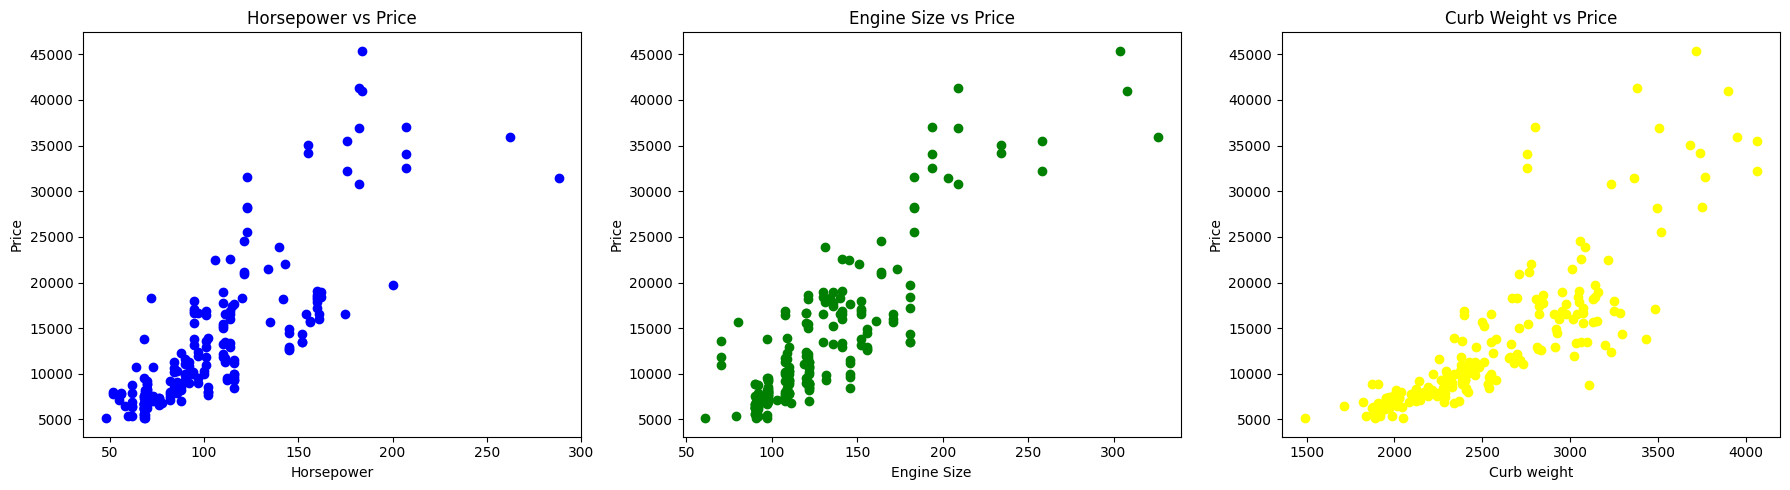

In [ ]:
# Create a grid of 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Horsepower
axes[0].scatter(df['horsepower'], df['price'], c='blue')
axes[0].set_xlabel('Horsepower')
axes[0].set_ylabel('Price')
axes[0].set_title('Horsepower vs Price')

# Plot 2: Engine Size
axes[1].scatter(df['enginesize'], df['price'], c='green')
axes[1].set_xlabel('Engine Size')
axes[1].set_ylabel('Price')
axes[1].set_title('Engine Size vs Price')

# Plot 3: Curb Weight
axes[2].scatter(df['curbweight'], df['price'], c='yellow')
axes[2].set_xlabel('Curb weight')
axes[2].set_ylabel('Price')
axes[2].set_title('Curb Weight vs Price')

plt.tight_layout() # Prevents labels from overlapping
plt.show()


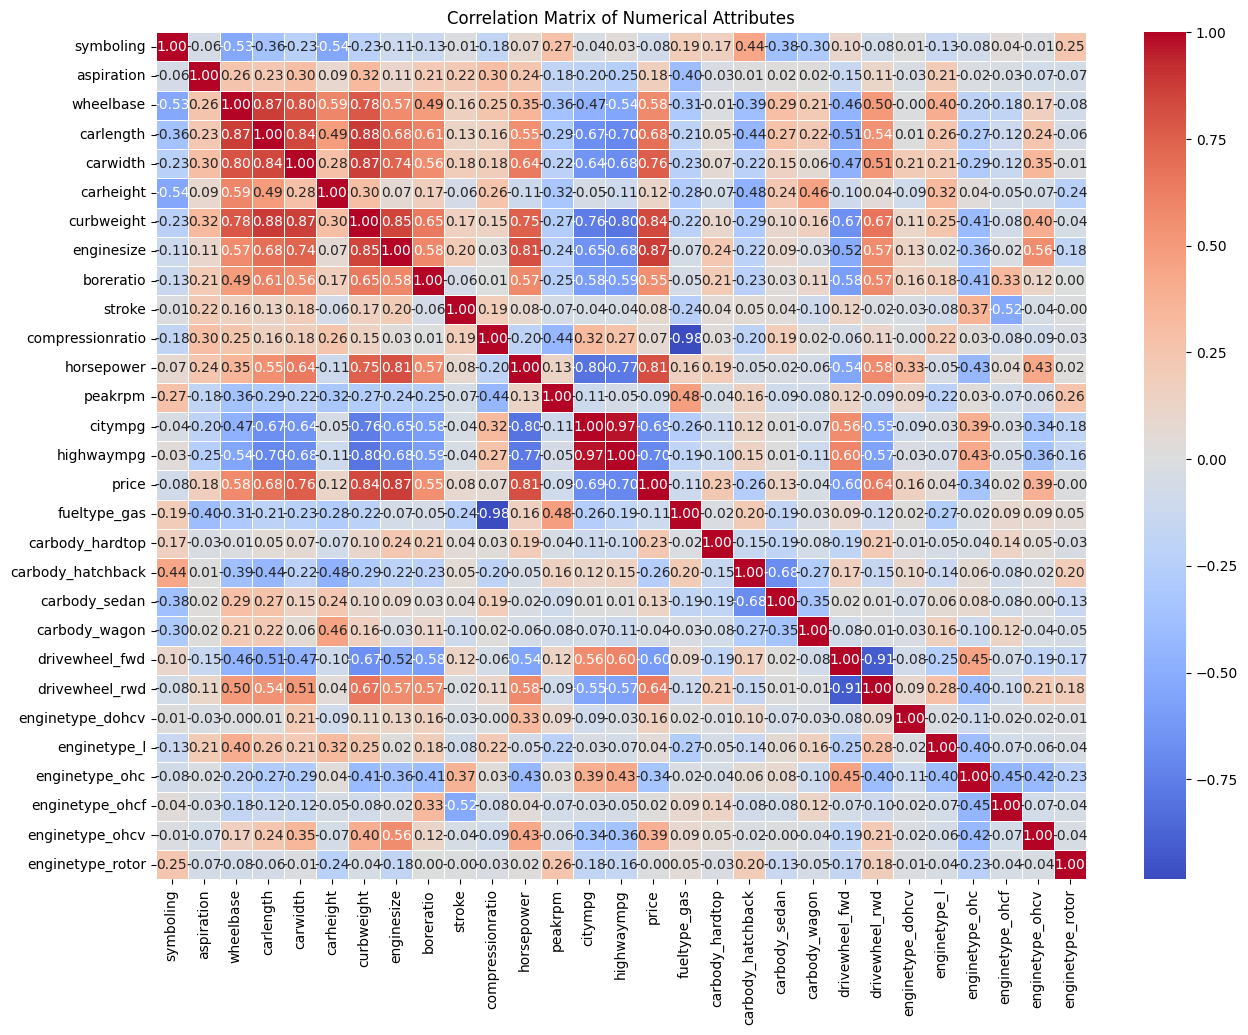

In [ ]:
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(15, 11))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Attributes')
plt.show()


From the correlation heatmap, you can observe the strength and direction of the linear relationship between each pair of numerical variables. Pay close attention to the 'price' row/column to identify which features have the strongest positive or negative correlation with car price. Generally, correlations closer to 1 or -1 indicate a stronger relationship.

## 4. Building Regression Model

In [ ]:
#Splitting the data
XTrain, XTest, yTrain, Ytest = train_test_split(X, y, test_size = 0.2)
#scaling the data
scaler = StandardScaler()
XTrainScaled = scaler.fit_transform(XTrain)
XTestScaled = scaler.transform(XTest)
# Fitting the model
reg = linreg()
reg.fit(XTrainScaled, yTrain)


[-0.6988985   2.20389266 -0.30073949 -0.01151737 -0.20833598  0.49976242
  0.17555233 -0.45224244  1.08610415 -1.96309644 -0.62898974  0.16906566
 -0.64303675 -0.36028385 -1.13314276  0.32879797 -0.22645541 -0.73970927
 -0.9067647   2.68328157 -1.13038833 -0.8        -0.07832604 -0.2409658
 -1.55456318  3.55902608 -0.28097574 -0.13650473]


In [ ]:
reg.score(XTestScaled, Ytest)

0.9105193597909056

In [ ]:
# Making Predictions
TestingData = XTestScaled[6]
print("Testing Data :")
print(TestingData)
actualValue = Ytest.iloc[6]
print(f"Actual Value(Price) : {actualValue}")
PredictedValue = reg.predict([TestingData])
print(f"Predicted Result (Predicted Price): {PredictedValue}")

Testing Data :
[ 1.7749005   2.20389266 -0.46970583 -0.04436691  0.21875278 -1.42632195
  0.68526994  0.64147568  0.97452277  1.94843407 -0.80631353  1.00480158
 -0.22579431 -0.9616737  -0.99084918  0.32879797 -0.22645541  1.35188247
 -0.9067647  -0.372678    0.88465174 -0.8        -0.07832604 -0.2409658
  0.64326752 -0.28097574 -0.28097574 -0.13650473]
Actual Value(Price) : 14869.0
Predicted Result (Predicted Price): [14449.70485751]


## 5. Evaluating the Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on the entire test set
Ypred = reg.predict(XTestScaled)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(Ytest, Ypred)
print(f'Mean Absolute Error (MAE): {mae:.2f}')

#Mean Squared Error
mse = mean_squared_error(Ytest, Ypred)
print(f'Mean Squareed Error (MSE): {mse:.2f}')

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(Ytest, Ypred))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

#R squared
Rsquared = reg.score(XTestScaled, Ytest)
print(f'R squared : {Rsquared}')


Mean Absolute Error (MAE): 1653.09
Mean Squareed Error (MSE): 4632978.52
Root Mean Squared Error (RMSE): 2152.44
R squared : 0.9105193597909056


## 6. Visualizations and Prediction

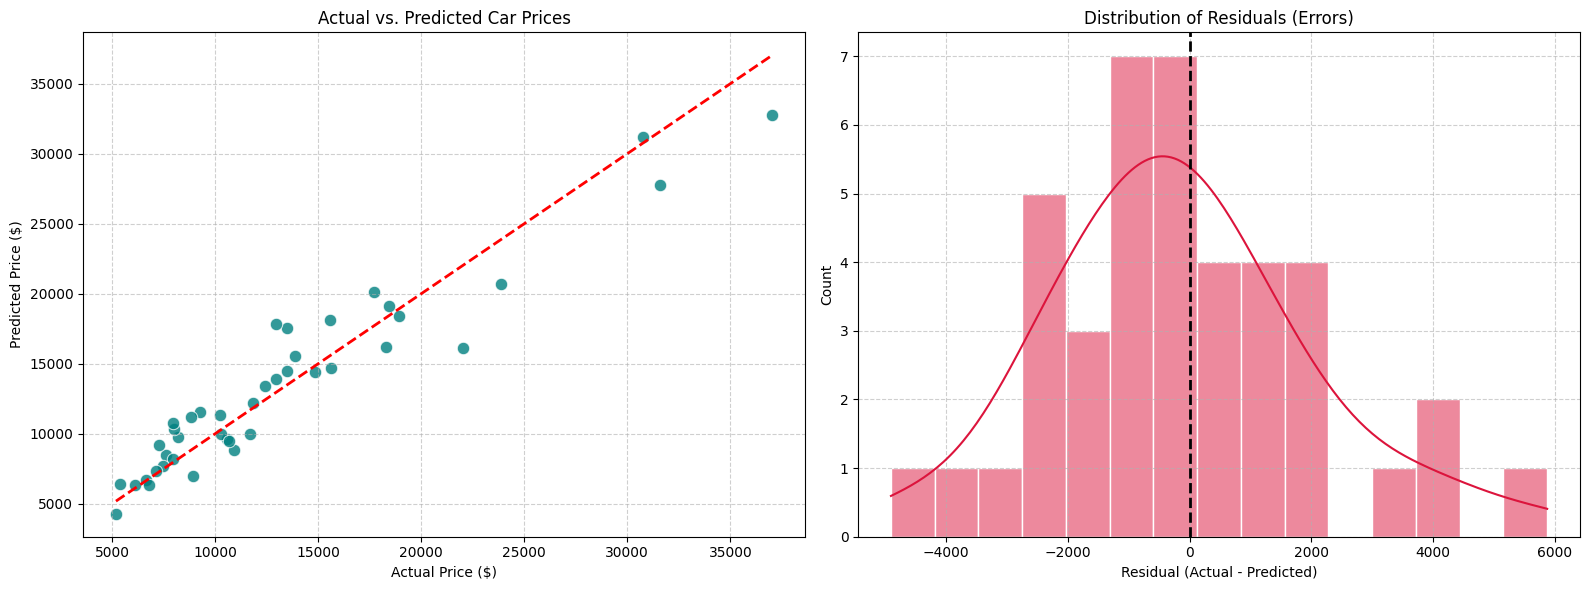

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = Ytest - Ypred

# Create a figure for evaluation plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted Prices
sns.scatterplot(x=Ytest, y=Ypred, ax=axes[0], color='teal', alpha=0.8, edgecolor='w', s=80)
axes[0].plot([Ytest.min(), Ytest.max()], [Ytest.min(), Ytest.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs. Predicted Car Prices')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Residuals Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='crimson', bins=15, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals (Errors)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Model Performance Interpretation

Based on our linear regression model metrics and plots:

1. **R-squared ($R^2$) of ~0.91**:
   * This suggests that approximately **91% of the variance** in car prices can be explained by our selected independent features (such as engine size, horsepower, curb weight, etc.). This indicates a highly predictive and strong linear relationship.

2. **Mean Absolute Error (MAE) of ~1,653.09**:
   * On average, our model's predictions deviate from the actual car prices by about **$1,653**. Given that car prices in this dataset range from $5,118 to $45,400, this average error is relatively small and acceptable.

3. **Root Mean Squared Error (RMSE) of ~2,152.44**:
   * The RMSE penalizes larger prediction errors more heavily than MAE. The fact that the RMSE ($2,152.44) is slightly higher than the MAE ($1,653.09) reveals that we have some larger errors (outliers), which is also apparent in our scatter and residual plots.

4. **Actual vs. Predicted Plot Analysis**:
   * The points are clustered closely along the red diagonal identity line ($y = x$), showing that our predictions are highly accurate across most price ranges. However, accuracy decreases slightly for luxury cars with prices above $30,000.

5. **Residuals Distribution Analysis**:
   * The residuals are centered around $0$, indicating that our model does not have a systemic bias (underestimating or overestimating consistently). The distribution resembles a normal curve, validating our assumption of normally distributed errors.

The Mean Absolute Error (MAE) tells you the average magnitude of errors in a set of predictions, without considering their direction. The Root Mean Squared Error (RMSE) is the square root of the average of the squared errors, giving more weight to larger errors. These metrics provide a more robust understanding of your model's predictive accuracy across all test data points, rather than focusing on a single, potentially anomalous prediction.

## 7. Prediction of New Car

In [ ]:
import numpy as np
import pandas as pd

# 1. Create a sample car matching the format of X (DataFrame)
# We'll take a copy of an existing row as a baseline to ensure all columns exist
sample_car = X.iloc[[0]].copy()

# 2. Modify attributes of our customized sample car
sample_car['symboling'] = 1
sample_car['aspiration'] = 1.0  # turbo
sample_car['wheelbase'] = 100.0
sample_car['carlength'] = 175.0
sample_car['carwidth'] = 66.0
sample_car['carheight'] = 54.0
sample_car['curbweight'] = 2800.0
sample_car['enginesize'] = 140.0
sample_car['boreratio'] = 3.5
sample_car['stroke'] = 3.15
sample_car['compressionratio'] = 9.0
sample_car['horsepower'] = 150.0
sample_car['peakrpm'] = 5500.0
sample_car['citympg'] = 22.0
sample_car['highwaympg'] = 28.0

# 3. Apply the fitted scaler to our sample features
sample_car_scaled = scaler.transform(sample_car)

# 4. Predict the selling price
predicted_price = reg.predict(sample_car_scaled)[0]

# Display the custom car details and the predicted price
print("=== Customized Sample Car Attributes ===")
for col in ['enginesize', 'horsepower', 'curbweight', 'citympg', 'highwaympg']:
    print(f"{col}: {sample_car[col].values[0]}")

print(f"\nPredicted Selling Price: ${predicted_price:,.2f}")

=== Customized Sample Car Attributes ===
enginesize: 140.0
horsepower: 150.0
curbweight: 2800.0
citympg: 22.0
highwaympg: 28.0

Predicted Selling Price: $21,280.85


# LAB 2: REGULARIZED REGRESSION USING LASSO AND RIDGE WITH CROSS VALIDATION AND GRID SEARCH

## Problem Statement

Select any suitable regression dataset containing multiple numerical features and a continuous target variable. Develop machine learning models using Lasso Regression and Ridge Regression to predict the target variable.
You must use GridSearchCV with appropriate cross-validation to determine the optimal value of the regularization parameter α (alpha) for both models.

## Objective

Implement and compare Lasso Regression and Ridge Regression by using Cross-Validation and Grid Search to identify the optimal penalty parameter.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso

## 1. Dataset Selection and Loading

In [ ]:
# Selected dataset: Diabetes Dataset
# loading the dataset
from sklearn.datasets import load_diabetes
data = load_diabetes(as_frame=True)
data

{'data':           age       sex       bmi        bp        s1        s2        s3  \
 0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
 1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
 2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
 3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
 4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
 ..        ...       ...       ...       ...       ...       ...       ...   
 437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
 438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
 439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
 440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
 441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   
 
            s4        s5        s6  
 0   -0.002592  0

## 2. Data Exploration

In [ ]:
df2 = load_diabetes(as_frame=True).frame
print(f"Number of rows : {df2.shape[0]}")
print(f"Number of columns : {df2.shape[1]}")
print("Missing Values : ")
print(df2.isnull().sum())
print("Duplicate Values : ")
print(df2.duplicated().sum())
print("\nDiscriptive Statistics :")
display(df2.describe())
display(df2.info())

Number of rows : 442
Number of columns : 11
Missing Values : 
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64
Duplicate Values : 
0

Discriptive Statistics :


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


None

In [ ]:
print("First Five Rows : ")
display(df2.head())

First Five Rows : 


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


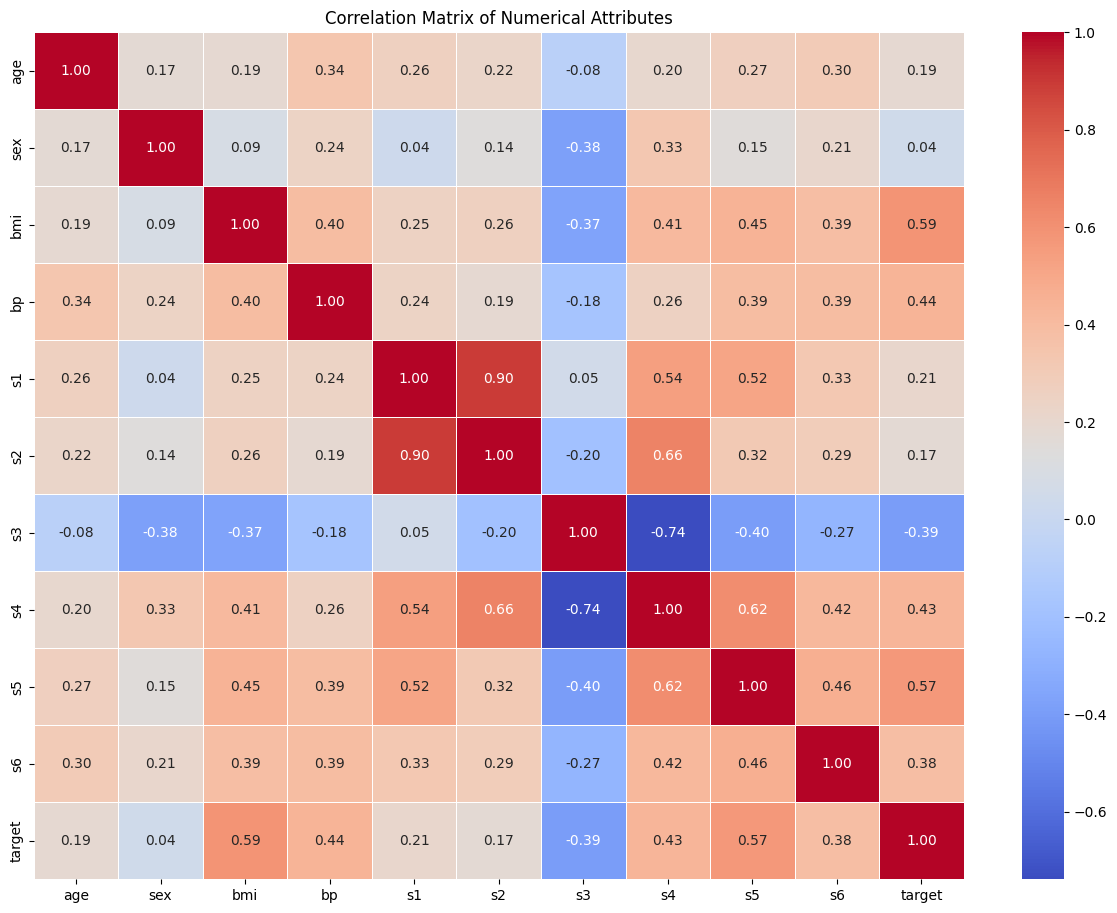

In [ ]:
# Relation Between features and target variable
numerical_data = df2.select_dtypes(include=['number'])
#Correlation
correlation_matrix = numerical_data.corr()

plt.figure(figsize=(15, 11))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Attributes')
plt.show()

## 3. Data Preprocessing

In [ ]:
# Seperating into features and target variables
X ,y = data.data, data.target
X, y

(          age       sex       bmi        bp        s1        s2        s3  \
 0    0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
 1   -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
 2    0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
 3   -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
 4    0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
 ..        ...       ...       ...       ...       ...       ...       ...   
 437  0.041708  0.050680  0.019662  0.059744 -0.005697 -0.002566 -0.028674   
 438 -0.005515  0.050680 -0.015906 -0.067642  0.049341  0.079165 -0.028674   
 439  0.041708  0.050680 -0.015906  0.017293 -0.037344 -0.013840 -0.024993   
 440 -0.045472 -0.044642  0.039062  0.001215  0.016318  0.015283 -0.028674   
 441 -0.045472 -0.044642 -0.073030 -0.081413  0.083740  0.027809  0.173816   
 
            s4        s5        s6  
 0   -0.002592  0.019907 

Since the data is already scaled, further scaling is not required

In [ ]:
# Splitting the data
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
print("Size of Training and testing data : ")
print("Training data : ",len(Xtrain), len(ytrain))
print("Testing Data : ",len(Xtest),len(ytest) )

Size of Training and testing data : 
Training data :  353 353
Testing Data :  89 89


## 4. Baseline Linear Regression Model

In [ ]:
LinReg = LinearRegression()
LinReg.fit(Xtrain,ytrain)

LinearRegression()

In [ ]:
# Evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make predictions on the entire test set
Ypred = LinReg.predict(Xtest)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(ytest, Ypred)
print(f'Mean Absolute Error (MAE): {mae:.2f}')

#Mean Squared Error
mse = mean_squared_error(ytest, Ypred)
print(f'Mean Squareed Error (MSE): {mse:.2f}')

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(ytest, Ypred))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

#R squared
Rsquared = LinReg.score(Xtest, ytest)
print(f'R squared : {Rsquared}')

Mean Absolute Error (MAE): 42.79
Mean Squareed Error (MSE): 2900.19
Root Mean Squared Error (RMSE): 53.85
R squared : 0.4526027629719195


## 5. Lasso Regression with grid search

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Lasso Regression
# We'll search for the optimal alpha (regularization strength)
param_grid_lasso = {
    'alpha': np.logspace(-4, 0, 100) # Alpha values from 0.0001 to 1
}

# Initialize Lasso Regression model
lasso = Lasso(random_state=42)

# Initialize GridSearchCV with 5-fold cross-validation
grid_search_lasso = GridSearchCV(estimator=lasso, param_grid=param_grid_lasso, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_lasso.fit(Xtrain, ytrain)


GridSearchCV(cv=5, estimator=Lasso(random_state=42), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-04, 1.09749877e-04, 1.20450354e-04, 1.32194115e-04,
       1.45082878e-04, 1.59228279e-04, 1.74752840e-04, 1.91791026e-04,
       2.10490414e-04, 2.31012970e-04, 2.53536449e-04, 2.78255940e-04,
       3.05385551e-04, 3.35160265e-04, 3.67837977e-04, 4.03701726e-04,
       4.43062146e-04, 4.86260...
       1.17681195e-01, 1.29154967e-01, 1.41747416e-01, 1.55567614e-01,
       1.70735265e-01, 1.87381742e-01, 2.05651231e-01, 2.25701972e-01,
       2.47707636e-01, 2.71858824e-01, 2.98364724e-01, 3.27454916e-01,
       3.59381366e-01, 3.94420606e-01, 4.32876128e-01, 4.75081016e-01,
       5.21400829e-01, 5.72236766e-01, 6.28029144e-01, 6.89261210e-01,
       7.56463328e-01, 8.30217568e-01, 9.11162756e-01, 1.00000000e+00])},
             scoring='neg_mean_squared_error')

In [ ]:
# Print the best alpha found by GridSearchCV
best_alpha_lasso = grid_search_lasso.best_params_['alpha']
print(f"Optimal alpha for Lasso Regression: {best_alpha_lasso:.4f}")

# Train the final Lasso model with the best alpha
final_lasso_model = Lasso(alpha=best_alpha_lasso, random_state=42)
final_lasso_model.fit(Xtrain, ytrain)


Optimal alpha for Lasso Regression: 0.0739


Lasso(alpha=np.float64(0.07390722033525783), random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluate the final Lasso model on the test set
ylasso_pred = final_lasso_model.predict(Xtest)

# Calculate evaluation metrics
mae_lasso = mean_absolute_error(ytest, ylasso_pred)
mse_lasso = mean_squared_error(ytest, ylasso_pred)
rmse_lasso = np.sqrt(mse_lasso)
r_squared_lasso = final_lasso_model.score(Xtest, ytest)

print("--- Lasso Regression Model Performance ---")
print(f'Mean Absolute Error (MAE): {mae_lasso:.2f}')
print(f'Mean Squared Error (MSE): {mse_lasso:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_lasso:.2f}')
print(f'R-squared: {r_squared_lasso:.4f}')


--- Lasso Regression Model Performance ---
Mean Absolute Error (MAE): 42.78
Mean Squared Error (MSE): 2800.96
Root Mean Squared Error (RMSE): 52.92
R-squared: 0.4713


## 6. Ridge Regression with Grid Search

In [ ]:
from sklearn.linear_model import Ridge

# Define the parameter grid for Ridge Regression
param_grid_ridge = {
    'alpha': np.logspace(-4, 2, 100) # Alpha values from 0.0001 to 100
}

# Initialize Ridge Regression model
ridge = Ridge(random_state=42)

# Initialize GridSearchCV with 5-fold cross-validation
grid_search_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid_ridge, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_ridge.fit(Xtrain, ytrain)


GridSearchCV(cv=5, estimator=Ridge(random_state=42), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226...
       4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02])},
             scoring='neg_mean_squared_error')

In [ ]:
# Print the best alpha found by GridSearchCV
best_alpha_ridge = grid_search_ridge.best_params_['alpha']
print(f"Optimal alpha for Ridge Regression: {best_alpha_ridge:.4f}")

# Train the final Ridge model with the best alpha
final_ridge_model = Ridge(alpha=best_alpha_ridge, random_state=42)
final_ridge_model.fit(Xtrain, ytrain)


Optimal alpha for Ridge Regression: 0.0614


Ridge(alpha=np.float64(0.061359072734131756), random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Evaluate the final Ridge model on the test set
yridge_pred = final_ridge_model.predict(Xtest)

# Calculate evaluation metrics
mae_ridge = mean_absolute_error(ytest, yridge_pred)
mse_ridge = mean_squared_error(ytest, yridge_pred)
rmse_ridge = np.sqrt(mse_ridge)
r_squared_ridge = final_ridge_model.score(Xtest, ytest)

print("--- Ridge Regression Model Performance ---")
print(f'Mean Absolute Error (MAE): {mae_ridge:.2f}')
print(f'Mean Squared Error (MSE): {mse_ridge:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse_ridge:.2f}')
print(f'R-squared: {r_squared_ridge:.4f}')


--- Ridge Regression Model Performance ---
Mean Absolute Error (MAE): 42.92
Mean Squared Error (MSE): 2863.37
Root Mean Squared Error (RMSE): 53.51
R-squared: 0.4596


## 7. Model Comparision

### Model Performance Comparison

In [ ]:
# Create a DataFrame to compare the metrics
performance_data = {
    'Model': ['Linear Regression', 'Lasso Regression', 'Ridge Regression'],
    'MAE': [mae, mae_lasso, mae_ridge],
    'MSE': [mse, mse_lasso, mse_ridge],
    'RMSE': [rmse, rmse_lasso, rmse_ridge],
    'R-squared': [Rsquared, r_squared_lasso, r_squared_ridge]
}

performance_df = pd.DataFrame(performance_data)
print("Model Performance Comparison:")
display(performance_df)


Model Performance Comparison:


,Model,MAE,MSE,RMSE,R-squared
0,Linear Regression,42.794095,2900.193628,53.853446,0.452603
1,Lasso Regression,42.779643,2800.962329,52.924119,0.471332
2,Ridge Regression,42.918172,2863.369490,53.510462,0.459553


### Optimal Alpha Values

In [ ]:
print(f"Optimal alpha for Lasso Regression: {best_alpha_lasso:.4f}")
print(f"Optimal alpha for Ridge Regression: {best_alpha_ridge:.4f}")


Optimal alpha for Lasso Regression: 0.0739
Optimal alpha for Ridge Regression: 0.0614


### Comparison of Regression Coefficients

In [ ]:
# Get feature names
feature_names = X.columns

# Get coefficients for each model
linear_coefficients = LinReg.coef_
lasso_coefficients = final_lasso_model.coef_
ridge_coefficients = final_ridge_model.coef_

# Create a DataFrame for coefficient comparison
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression Coeff': linear_coefficients,
    'Lasso Regression Coeff': lasso_coefficients,
    'Ridge Regression Coeff': ridge_coefficients
})

# Sort by absolute value of linear regression coefficient for better readability
coefficients_df['Abs_Linear_Coeff'] = np.abs(coefficients_df['Linear Regression Coeff'])
coefficients_df = coefficients_df.sort_values(by='Abs_Linear_Coeff', ascending=False).drop(columns=['Abs_Linear_Coeff'])

print("Regression Coefficients Comparison:")
display(coefficients_df)


Regression Coefficients Comparison:


,Feature,Linear Regression Coeff,Lasso Regression Coeff,Ridge Regression Coeff
4,s1,-931.488846,-105.830848,-147.065999
8,s5,736.198859,463.038341,417.523711
2,bmi,542.428759,554.410479,523.346372
5,s2,518.062277,-0.000000,-70.002610
3,bp,347.703844,313.229846,326.578244
7,s4,275.317902,0.000000,159.116836
1,sex,-241.964362,-171.167941,-217.952290
6,s3,163.419983,-236.277707,-179.653152
9,s6,48.670657,38.331968,71.466649
0,age,37.904021,0.000000,42.403108


### Features with Zero Coefficients in Lasso Regression

In [ ]:
# Identify features whose coefficients became zero in Lasso
zero_lasso_coefficients = coefficients_df[coefficients_df['Lasso Regression Coeff'] == 0.0]

if not zero_lasso_coefficients.empty:
    print("The following features had their coefficients set to zero by Lasso Regression (indicating feature selection):")
    display(zero_lasso_coefficients[['Feature', 'Lasso Regression Coeff']])
else:
    print("No features had their coefficients explicitly set to zero by Lasso Regression in this instance.")


The following features had their coefficients set to zero by Lasso Regression (indicating feature selection):


,Feature,Lasso Regression Coeff
5,s2,-0.0
7,s4,0.0
0,age,0.0


## 8. Visualization

### Actual vs. Predicted Values for Lasso and Ridge Regression

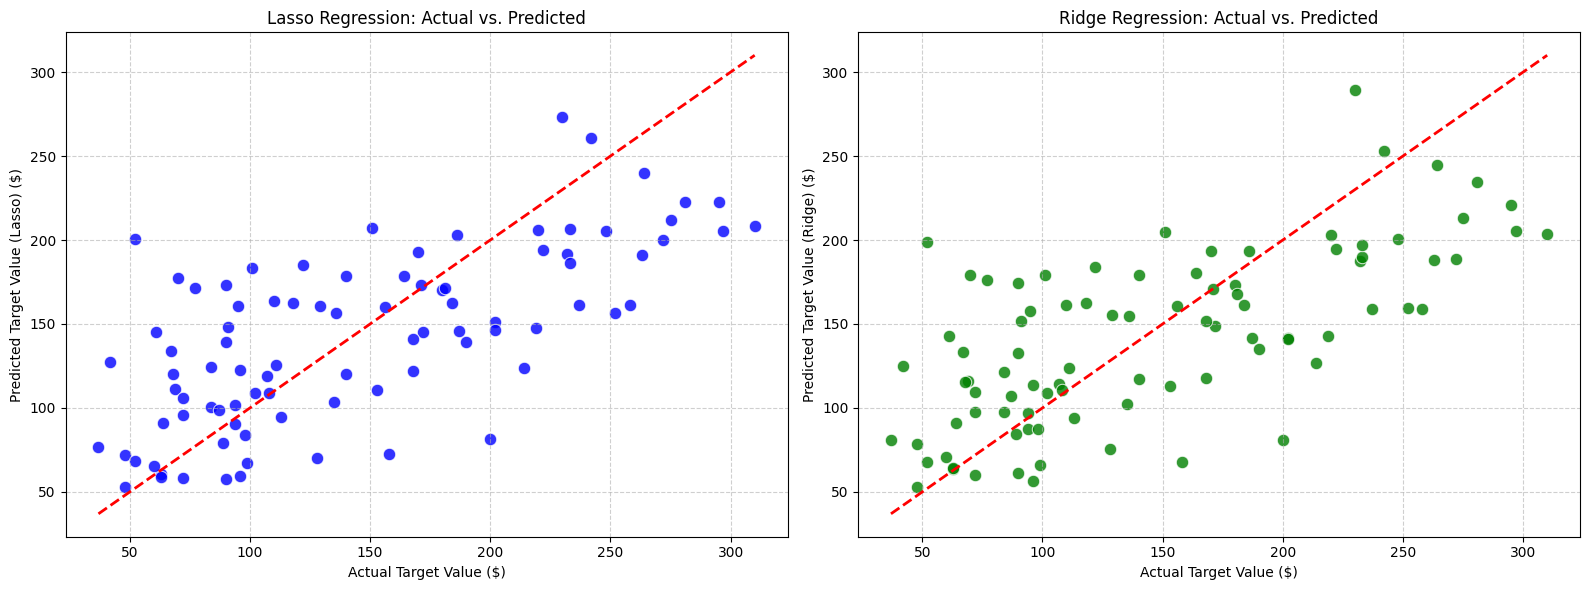

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Lasso Regression
sns.scatterplot(x=ytest, y=ylasso_pred, ax=axes[0], color='blue', alpha=0.8, edgecolor='w', s=80)
axes[0].plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Target Value ($)')
axes[0].set_ylabel('Predicted Target Value (Lasso) ($)')
axes[0].set_title('Lasso Regression: Actual vs. Predicted')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot for Ridge Regression
sns.scatterplot(x=ytest, y=yridge_pred, ax=axes[1], color='green', alpha=0.8, edgecolor='w', s=80)
axes[1].plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Target Value ($)')
axes[1].set_ylabel('Predicted Target Value (Ridge) ($)')
axes[1].set_title('Ridge Regression: Actual vs. Predicted')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Comparison of Feature Coefficients

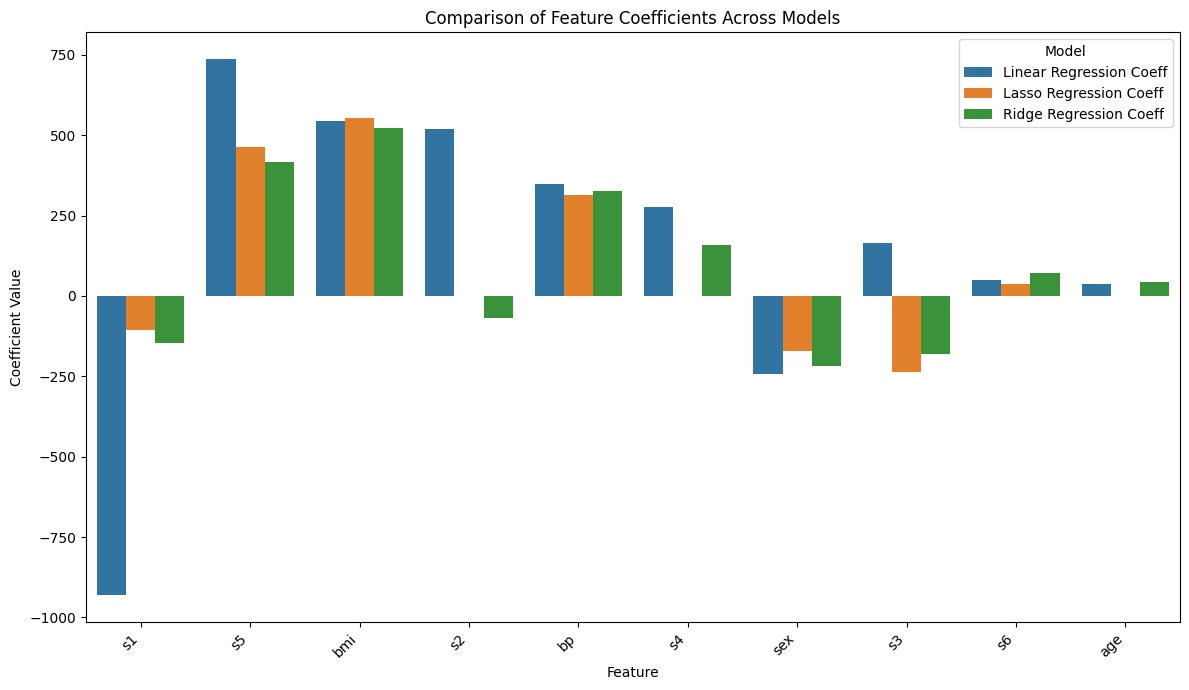

In [ ]:
plt.figure(figsize=(12, 7))
coefficients_df_melted = coefficients_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
sns.barplot(x='Feature', y='Coefficient', hue='Model', data=coefficients_df_melted)
plt.xticks(rotation=45, ha='right')
plt.title('Comparison of Feature Coefficients Across Models')
plt.ylabel('Coefficient Value')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()


### Cross-Validation Performance vs. Alpha Values

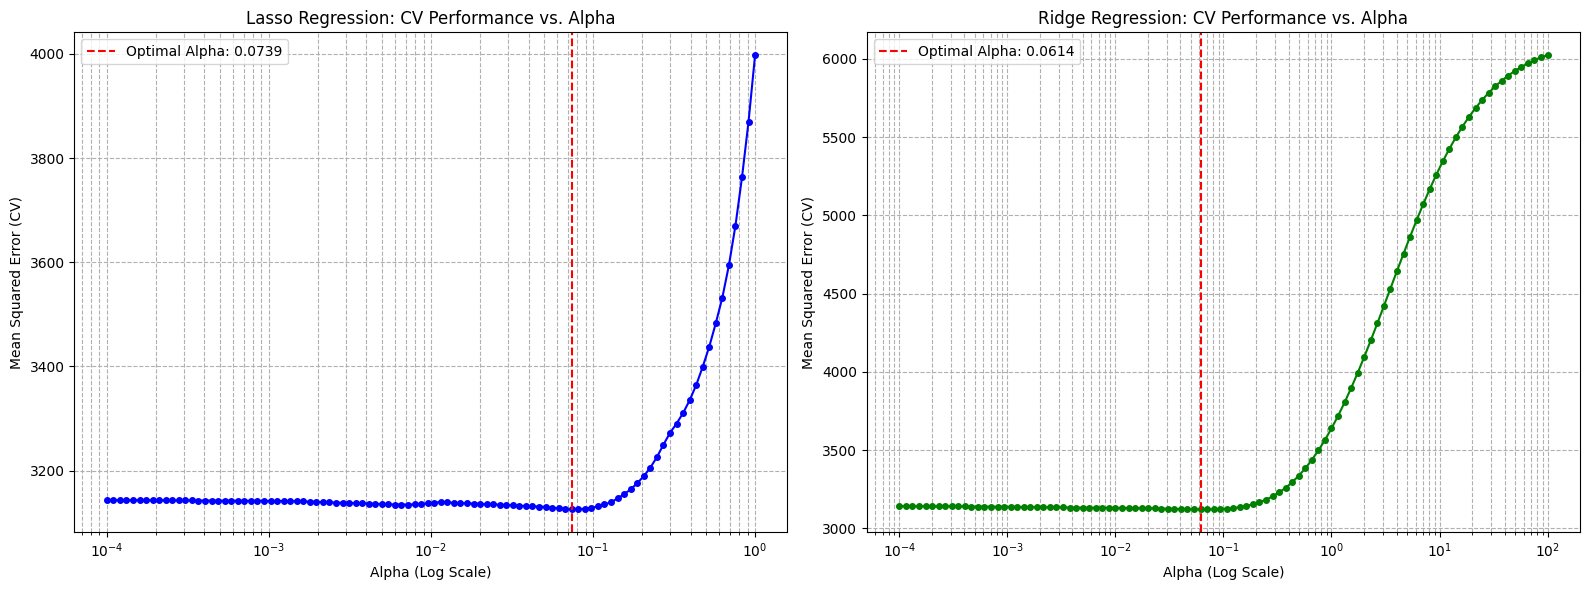

In [ ]:
# Get results from GridSearchCV for Lasso
lasso_cv_results = pd.DataFrame(grid_search_lasso.cv_results_)

# Get results from GridSearchCV for Ridge
ridge_cv_results = pd.DataFrame(grid_search_ridge.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Lasso CV performance
axes[0].plot(lasso_cv_results['param_alpha'], -lasso_cv_results['mean_test_score'], marker='o', linestyle='-', markersize=4, color='blue')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (Log Scale)')
axes[0].set_ylabel('Mean Squared Error (CV)')
axes[0].set_title('Lasso Regression: CV Performance vs. Alpha')
axes[0].grid(True, which="both", ls="--")
axes[0].axvline(best_alpha_lasso, color='r', linestyle='--', label=f'Optimal Alpha: {best_alpha_lasso:.4f}')
axes[0].legend()

# Plot Ridge CV performance
axes[1].plot(ridge_cv_results['param_alpha'], -ridge_cv_results['mean_test_score'], marker='o', linestyle='-', markersize=4, color='green')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (Log Scale)')
axes[1].set_ylabel('Mean Squared Error (CV)')
axes[1].set_title('Ridge Regression: CV Performance vs. Alpha')
axes[1].grid(True, which="both", ls="--")
axes[1].axvline(best_alpha_ridge, color='r', linestyle='--', label=f'Optimal Alpha: {best_alpha_ridge:.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Interpretation

**How changing the alpha value affects model performance:**

alpha (or lambda) is the regularization strength parameter. A higher alpha value means stronger regularization.
Low alpha (weak regularization): The model behaves very similarly to standard Linear Regression. It tries to fit the training data as closely as possible, which can lead to overfitting if the model is too complex for the data.

**Optimal alpha**:

This value balances bias and variance, leading to the best generalization performance on unseen data. Your cross-validation plots (Mean Squared Error vs. Alpha) for both Lasso and Ridge clearly show a 'sweet spot' where the MSE is minimized, indicating the optimal alpha that you found.
High alpha (strong regularization): The model coefficients are heavily penalized. For Lasso, this drives more coefficients to exactly zero, performing aggressive feature selection. For Ridge, it shrinks coefficients significantly towards zero. Both can lead to underfitting if alpha is too high, as the model becomes too simple to capture the underlying patterns in the data.

**The effect of regularization on model coefficients:**

Lasso (L1 Regularization): Adds a penalty proportional to the absolute value of the coefficients. This penalty has the effect of shrinking some coefficients exactly to zero. This is why Lasso is often used for feature selection, as it effectively removes irrelevant features from the model. In your results, Lasso set coefficients for 's2', 's4', and 'age' to zero, demonstrating this effect.

Ridge (L2 Regularization): Adds a penalty proportional to the square of the magnitude of the coefficients. This penalty shrinks coefficients towards zero but rarely makes them exactly zero. It reduces the impact of less important features without fully removing them. You can observe in your coefficient comparison plot that Ridge coefficients are generally smaller in magnitude than Linear Regression coefficients but none are exactly zero (unlike Lasso).

**Why feature scaling is important for Lasso and Ridge Regression:**

Regularization techniques like Lasso and Ridge are sensitive to the scale of the features. This is because the penalty term (e.g., alpha * sum(|coefficients|) for Lasso) is applied to the coefficients directly. If features are on different scales:

A feature with a larger value range will have a larger coefficient (all else being equal) to have the same impact on the target variable as a feature with a smaller value range.
The regularization penalty will disproportionately penalize features with larger coefficients, irrespective of their actual importance. This means features with naturally larger scales might be unfairly shrunk or eliminated.
Scaling  ensures that all features contribute equally to the regularization penalty, preventing features with large values from dominating the penalty term. This allows the regularization to properly identify and penalize less important features based on their true predictive power, rather than their scale.

**Whether Lasso or Ridge is more suitable for the selected dataset**

based on the experimental results: Looking at the "Model Performance Comparison" table:

R-squared: Lasso has the highest R-squared (0.4713), slightly outperforming Ridge (0.4596) and Linear Regression (0.4526). A higher R-squared indicates that more variance in the target variable is explained by the model.
MAE, MSE, RMSE: Lasso also shows slightly lower MAE (42.78), MSE (2800.96), and RMSE (52.92) compared to Ridge (MAE 42.92, MSE 2863.37, RMSE 53.51) and Linear Regression. Lower values for these metrics indicate better predictive accuracy.
Feature Selection: Lasso explicitly set the coefficients for 's2', 's4', and 'age' to zero, indicating that these features might be redundant or less impactful for prediction in this dataset, and Lasso was able to identify this.

**Conclusion:**

Based on these results, **Lasso Regression** appears to be slightly more suitable for this specific Diabetes dataset. It achieved marginally better performance metrics (higher R-squared, lower errors) and performed automatic feature selection, which can lead to a simpler, more interpretable model without sacrificing predictive power. This suggests that some features in the dataset might indeed be irrelevant or highly correlated, and Lasso successfully identified and removed their influence.
